# Exercise 5 — Transfer Learning with ResNet18 (Fashion-MNIST)

**Objective (from the assignment):** train a pre-trained ResNet on one of the Exercise-4 datasets, evaluate it, and **compare** it against the custom CNN built in Exercise 4.

We use **Fashion-MNIST** (the dataset from Exercise 4). The notebook follows the assignment structure:
1. Setup and data preparation (resize to ResNet input, ImageNet normalization, augmentation)
2. Model building (pre-trained ResNet18, replace the head, freeze, then fine-tune)
3. Training (scheduler, monitor accuracy / precision / recall / F1, save the best model)
4. Evaluation (test set metrics, confusion matrix, loss/accuracy curves)
5. Comparison and conclusions (ResNet vs the Exercise-4 CNN, comparison table)

> Section 5 loads `cnn_best.pt` produced by Exercise 4. Make sure that file is reachable (see the `CNN_PATH` variable).


In [1]:
# Avoid the OpenMP/MKL "duplicate libiomp5" crash that can silently kill the
# kernel on local installs (must run before importing torch / numpy / matplotlib).
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import FashionMNIST
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_recall_fscore_support, accuracy_score)
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 0. Hyperparameters

All knobs in one place. `IMG_SIZE` is 224 to match ResNet's native input (as the assignment suggests). On a CPU this is slow — setting `IMG_SIZE = 64` trains much faster with only a small quality cost, which is a reasonable choice if you have no GPU.


In [2]:
IMG_SIZE      = 224      # ResNet input size (assignment: "e.g., 224x224"). Use 64 for faster CPU runs.
BATCH_SIZE    = 64
FREEZE_EPOCHS = 3        # epochs training only the new fc head
TOTAL_EPOCHS  = 8        # total epochs (fine-tuning starts after FREEZE_EPOCHS)
BASE_LR       = 1e-3
SEED          = 42

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

## 1. Setup and Data Preparation

ResNet was pre-trained on 3-channel ImageNet images, so we adapt grayscale Fashion-MNIST: resize to `IMG_SIZE`, replicate the single channel to three (`Grayscale(3)`), and normalize with the ImageNet statistics. Per the assignment we add **augmentation** to the training set only — horizontal flips, small rotations, and color jitter — to improve generalization. The evaluation transform has no augmentation.

We split the training data 80/20 into train/validation (using `Subset` over two dataset views so train can be augmented while validation stays clean), and keep the official Fashion-MNIST test set separate for the final evaluation.


In [3]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),          # 1 channel -> 3 (replicated)
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # color jitter (augmentation)
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

train_aug    = FashionMNIST(root="./data", train=True,  download=True, transform=train_transform)
train_plain  = FashionMNIST(root="./data", train=True,  download=True, transform=eval_transform)
test_dataset = FashionMNIST(root="./data", train=False, download=True, transform=eval_transform)
class_names  = train_aug.classes

g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(len(train_aug), generator=g).tolist()
split = int(0.8 * len(perm))
train_idx, val_idx = perm[:split], perm[split:]
train_dataset = Subset(train_aug,   train_idx)
val_dataset   = Subset(train_plain, val_idx)

# num_workers=0 is the safe cross-platform default; raise it on Linux/Colab for speed.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print("Train / Val / Test:", len(train_dataset), len(val_dataset), len(test_dataset))
xb, yb = next(iter(train_loader))
print("Batch shape:", xb.shape)   # [BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE]

Train / Val / Test: 48000 12000 10000
Batch shape: torch.Size([64, 3, 224, 224])


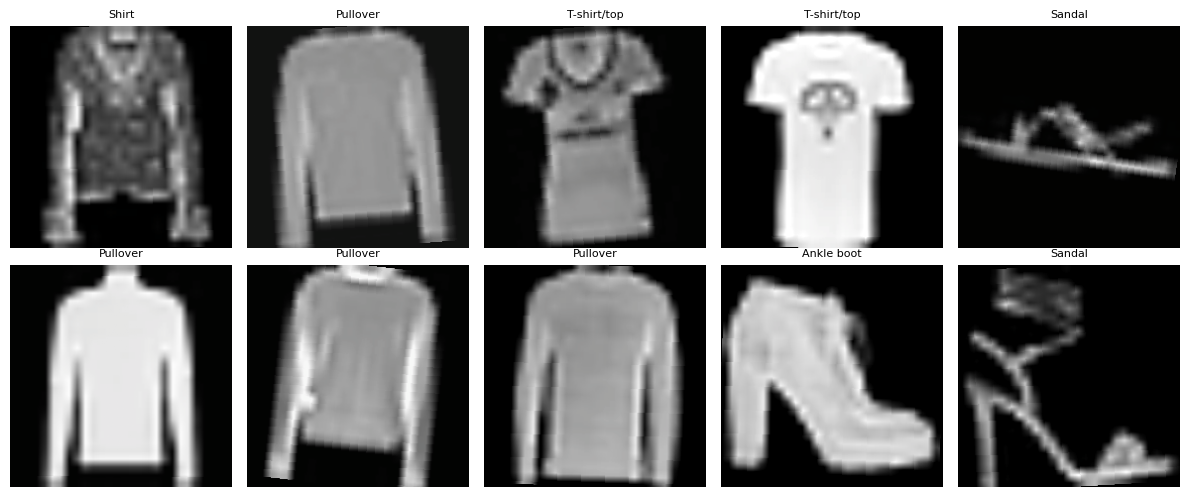

In [4]:
# Quick look at a few augmented training images (inverse-normalized for display)
inv_normalize = transforms.Normalize(
    mean=[-m / s for m, s in zip(imagenet_mean, imagenet_std)],
    std=[1 / s for s in imagenet_std],
)
xb, yb = next(iter(train_loader))
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, i in zip(axes.flatten(), range(10)):
    img = np.clip(inv_normalize(xb[i]).permute(1, 2, 0).numpy(), 0, 1)
    ax.imshow(img); ax.set_title(class_names[yb[i].item()], fontsize=8); ax.axis("off")
plt.tight_layout(); plt.show()

## 2. Model Building

Load ResNet18 with ImageNet weights, **freeze all parameters**, and replace the final fully-connected layer with a new one that has 10 outputs (one per Fashion-MNIST class). Only the new head is trainable at first; we unfreeze the last convolutional block (`layer4`) later for fine-tuning.


In [5]:
num_classes = 10
model = resnet18(weights=ResNet18_Weights.DEFAULT)   # pre-trained on ImageNet

for p in model.parameters():        # freeze all pretrained layers
    p.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, num_classes)   # new trainable head (512 -> 10)
model = model.to(device)

print("Trainable params (head only):", sum(p.numel() for p in model.parameters() if p.requires_grad))

Trainable params (head only): 5130


## 3. Training

Strategy from the assignment: start by training only the fully-connected head, then **enable fine-tuning** by unfreezing the last convolutional block (`layer4`) after a few epochs, using a smaller learning rate for it so the pre-trained features are nudged, not destroyed. We use Adam, a `StepLR` scheduler, `CrossEntropyLoss`, and we monitor accuracy / precision / recall / F1 on the validation set each epoch. The best model (by validation accuracy) is saved with `torch.save`.


In [6]:
from tqdm import tqdm   # text-based progress bar (avoids the ipywidgets "Error displaying widget")

def run_epoch(model, loader, criterion, optimizer=None):
    train = optimizer is not None
    model.train() if train else model.eval()
    total_loss, preds, tgts = 0.0, [], []
    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for x, y in tqdm(loader, leave=False):
            x, y = x.to(device), y.to(device)
            if train:
                optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            if train:
                loss.backward(); optimizer.step()
            total_loss += loss.item() * x.size(0)
            preds.append(logits.argmax(1).cpu()); tgts.append(y.cpu())
    preds = torch.cat(preds).numpy(); tgts = torch.cat(tgts).numpy()
    acc = accuracy_score(tgts, preds)
    p, r, f1, _ = precision_recall_fscore_support(tgts, preds, average="macro", zero_division=0)
    return total_loss / len(preds), acc, p, r, f1

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=BASE_LR)               # phase 1: head only
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

history = {k: [] for k in ["train_loss","train_acc","val_loss","val_acc","val_prec","val_rec","val_f1"]}
best_val_acc, best_state = 0.0, copy.deepcopy(model.state_dict())

for epoch in range(1, TOTAL_EPOCHS + 1):
    if epoch == FREEZE_EPOCHS + 1:
        print(">> Fine-tuning: unfreezing layer4 (smaller LR for it)\n")
        for p in model.layer4.parameters():
            p.requires_grad = True
        optimizer = optim.Adam([
            {"params": model.layer4.parameters(), "lr": BASE_LR / 5},
            {"params": model.fc.parameters(),     "lr": BASE_LR},
        ], weight_decay=1e-4)
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

    tr_loss, tr_acc, _, _, _              = run_epoch(model, train_loader, criterion, optimizer)
    va_loss, va_acc, va_p, va_r, va_f1   = run_epoch(model, val_loader,   criterion)
    scheduler.step()

    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss);   history["val_acc"].append(va_acc)
    history["val_prec"].append(va_p); history["val_rec"].append(va_r); history["val_f1"].append(va_f1)
    print(f"Epoch {epoch:2d}/{TOTAL_EPOCHS} | train_acc={tr_acc:.4f} "
          f"| val_acc={va_acc:.4f} P={va_p:.4f} R={va_r:.4f} F1={va_f1:.4f}")

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_state = copy.deepcopy(model.state_dict())

print("\nBest validation accuracy:", round(best_val_acc, 4))
model.load_state_dict(best_state)
torch.save(best_state, "resnet18_fashionmnist_best.pt")
print("Saved best model -> resnet18_fashionmnist_best.pt")

Epoch  1/8 | train_acc=0.7530 | val_acc=0.8059 P=0.8111 R=0.8065 F1=0.8062


Epoch  2/8 | train_acc=0.8124 | val_acc=0.8116 P=0.8165 R=0.8112 F1=0.8061


Epoch  3/8 | train_acc=0.8209 | val_acc=0.8051 P=0.8162 R=0.8058 F1=0.7978
>> Fine-tuning: unfreezing layer4 (smaller LR for it)



Epoch  4/8 | train_acc=0.8760 | val_acc=0.8997 P=0.9036 R=0.8991 F1=0.8991


Epoch  5/8 | train_acc=0.9106 | val_acc=0.9143 P=0.9157 R=0.9145 F1=0.9145


Epoch  6/8 | train_acc=0.9215 | val_acc=0.9218 P=0.9221 R=0.9224 F1=0.9220


Epoch  7/8 | train_acc=0.9410 | val_acc=0.9334 P=0.9330 R=0.9338 F1=0.9333


Epoch  8/8 | train_acc=0.9463 | val_acc=0.9323 P=0.9325 R=0.9323 F1=0.9323

Best validation accuracy: 0.9334
Saved best model -> resnet18_fashionmnist_best.pt


## 4. Evaluation

Evaluate the best model on the held-out **test set**: accuracy, precision, recall, F1, a full classification report, and a confusion matrix. We also plot the training/validation loss and accuracy curves.


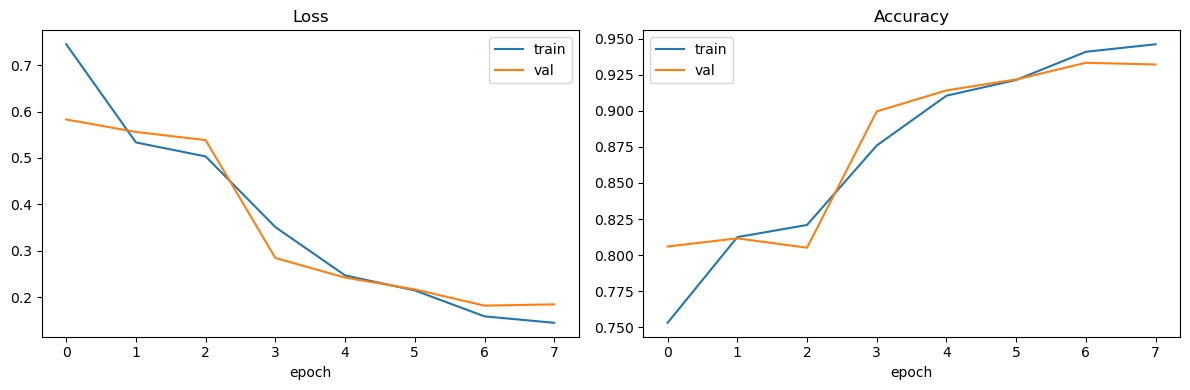

In [7]:
# Training / validation curves
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history["train_loss"], label="train"); ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(history["train_acc"], label="train"); ax[1].plot(history["val_acc"], label="val")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

ResNet18 TEST -> acc=0.9307  precision=0.9304  recall=0.9307  F1=0.9305

              precision    recall  f1-score   support

 T-shirt/top     0.8893    0.8760    0.8826      1000
     Trouser     0.9930    0.9880    0.9905      1000
    Pullover     0.8959    0.9120    0.9039      1000
       Dress     0.9210    0.9330    0.9270      1000
        Coat     0.8912    0.9090    0.9000      1000
      Sandal     0.9802    0.9910    0.9856      1000
       Shirt     0.7971    0.7700    0.7833      1000
     Sneaker     0.9625    0.9750    0.9687      1000
         Bag     0.9910    0.9910    0.9910      1000
  Ankle boot     0.9826    0.9620    0.9722      1000

    accuracy                         0.9307     10000
   macro avg     0.9304    0.9307    0.9305     10000
weighted avg     0.9304    0.9307    0.9305     10000



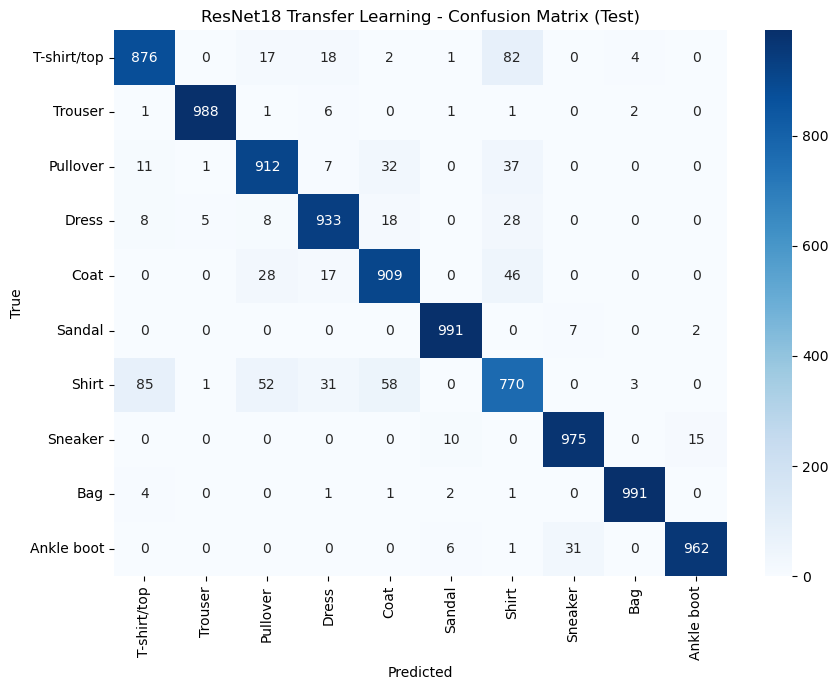

In [8]:
@torch.no_grad()
def predict_all(model, loader):
    model.eval(); ys, ps = [], []
    for x, y in loader:
        ps.append(model(x.to(device)).argmax(1).cpu().numpy()); ys.append(y.numpy())
    return np.concatenate(ys), np.concatenate(ps)

y_true, y_pred = predict_all(model, test_loader)
acc = accuracy_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
print(f"ResNet18 TEST -> acc={acc:.4f}  precision={prec:.4f}  recall={rec:.4f}  F1={f1:.4f}\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("ResNet18 Transfer Learning - Confusion Matrix (Test)")
plt.tight_layout(); plt.show()

## 5. Comparison and Conclusions

The assignment requires comparing transfer learning against the custom CNN from Exercise 4. We load the saved CNN (`cnn_best.pt`) and evaluate it on the **same Fashion-MNIST test set** — but with **its own preprocessing** (28x28, 1 channel, normalized to [-1, 1]), since that is what it was trained on. Same data, model-appropriate input: that keeps the comparison fair.

The `CNN` class below must match the Exercise-4 architecture exactly, or `load_state_dict` will fail.


In [9]:
# Must match the Exercise-4 architecture exactly
class CNN(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(64 * 7 * 7, 512)
        self.fc2 = nn.Linear(512, 10)
    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Path to the model saved by Exercise 4. On Windows use a raw string (r"...").
# For Colab, upload cnn_best.pt and set CNN_PATH = "cnn_best.pt".
CNN_PATH = r"C:\Users\liory\Downloads\Deep_Learning_Course_git\Homework_5_Transfer_Lerning\cnn_best.pt"

# CNN preprocessing: 28x28, 1 channel, normalized to [-1, 1]
cnn_eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])
cnn_test = FashionMNIST(root="./data", train=False, download=True, transform=cnn_eval_transform)
cnn_test_loader = DataLoader(cnn_test, batch_size=64, shuffle=False)

cnn_model = CNN().to(device)
cnn_model.load_state_dict(torch.load(CNN_PATH, map_location=device))
cnn_model.eval()

y_true_cnn, y_pred_cnn = predict_all(cnn_model, cnn_test_loader)
print(f"CNN test accuracy: {accuracy_score(y_true_cnn, y_pred_cnn) * 100:.2f}%")

C:\Users\liory\AppData\Local\Temp\ipykernel_19440\2108387265.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cnn_model.load_state_dict(torch.load(CNN_PATH, map_location

CNN test accuracy: 92.00%


In [10]:
import pandas as pd

def all_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return acc, p, r, f1

cnn_m = all_metrics(y_true_cnn, y_pred_cnn)
res_m = all_metrics(y_true, y_pred)

comparison = pd.DataFrame(
    [["Custom CNN (Exercise 4)", *cnn_m],
     ["ResNet18 Transfer Learning (Exercise 5)", *res_m]],
    columns=["Model", "Accuracy", "Precision", "Recall", "F1"],
).set_index("Model")
comparison.round(4)

,Accuracy,Precision,Recall,F1
Model,,,,
Custom CNN (Exercise 4),0.9200,0.9193,0.9200,0.9194
ResNet18 Transfer Learning (Exercise 5),0.9307,0.9304,0.9307,0.9305


### Conclusions

_Fill this in based on your actual results (the assignment's Report Document asks for these points):_

- **Accuracy / metrics:** which model scored higher on the test set, and by how much (see the table above)?
- **Convergence & training time:** transfer learning trains far fewer parameters at first, so it usually converges in fewer epochs. How did the loss curves compare?
- **When transfer learning helps vs. training from scratch:** pre-trained features give a big head start on complex/limited-data problems; on a simple, plentiful dataset like Fashion-MNIST a small purpose-built CNN can be very competitive.
- **Challenges:** e.g. adapting grayscale to 3 channels, the cost of 224x224 inputs, deciding which layers to unfreeze, and choosing the fine-tuning learning rate.
